# 모델 개발과 평가 — Batch1 선정, Batch2 평가

100사이클 관측 후 원래 사이클 단위 `cycle_life`를 예측하는 회귀다. 변수·모델·하이퍼파라미터 선택에는 Batch1만 사용한다. Batch2는 모델을 고정한 뒤 평가하고 Batch3은 사용하지 않는다.

Feature Engineering에서 전달한 후보는 L(로그 분산), E(이상적 평균 충전속도), T(평균 온도·충전 부담 조합)다. 후보를 모두 넣는 대신 L / L+E / L+T / L+E+T의 추가 효과를 비교한다.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "model"))
from train_model import select_model, evaluate_model
OUT = ROOT / "outputs"

## 1. 분할과 선정 기준

Batch1 46개 셀의 수치형 충전 프로토콜을 그룹으로 묶어 `GroupShuffleSplit(test_size=0.2, random_state=42)`으로 학습 35개와 Hold-out 11개를 분리한다. 같은 프로토콜은 양쪽에 겹치지 않는다.

학습 35개 안에서 동일한 5-fold GroupKFold를 모든 후보에 적용한다. `StandardScaler → 회귀 모델` Pipeline은 각 fold train에서만 변환 기준을 학습한다. 시간 순서의 cycle 행을 무작위 분할하지 않고, 셀당 초기 100사이클에서 생성한 한 행을 사용한다.

각 후보의 파라미터는 CV 평균 MAPE 최소값으로 선택한다. 전체 최소 MAPE에 그 후보의 fold 오차 표준오차(표본 표준편차 / √5)를 더한 범위에 들어오는 후보 중 **변수 수 → 모델 단순성 → fold 오차 표준편차 → 평균 MAPE** 순으로 선택한다. 단순성 순서는 선형회귀, Ridge, 얕은 의사결정나무, SVR, Random Forest로 미리 정한다. 1-SE 범위는 성능이 비슷한 후보를 고르는 규칙이며 유의성 검정으로 해석하지 않는다.

Hold-out·Batch2 점수는 선정에 사용하지 않는다. CV는 모델·파라미터를 선택하는 점수이며 별도 Hold-out에서 고정 모델을 검증한다.

## 2. 후보 모델과 역할

| 모델 | 확인할 내용 | 제한한 파라미터 |
|---|---|---|
| 선형회귀 | 로그 지표의 직선 경향과 해석 가능한 기준 | 규제 없음 |
| Ridge | 입력 중복이 남을 때 L2 규제로 계수 크기 억제 | α=0.001, 0.01, 0.1, 1, 10, 100 |
| 의사결정나무 | 특정 값에서 수명이 달라지는 구간 관계 | 깊이 2·3·4, 최소 잎 3·5 |
| SVR(RBF) | 매끄러운 비선형 관계 | C=100·1000·10000, ε=10·50사이클, γ=scale·0.1 |
| Random Forest | 나무의 구간·조합 관계를 평균해 확인 | 100개 나무, 깊이 2·4·무제한, 최소 잎 2·4 |

나무 모델의 난수는 42로 고정한다. 작은 Batch1 표본에서 많은 탐색을 피하고 같은 분할·지표로 비교한다. 입력의 개수가 모델 종류를 결정하지 않는다.

In [2]:
state = select_model(OUT)
selection = state["selection"]
comparison = pd.DataFrame(selection["comparison"])
display(comparison[["candidate", "CV_MAPE_pct", "CV_std_pp", "params", "within_one_se"]]
        .sort_values("CV_MAPE_pct").round(3))
print("학습 / 검증:", len(state["train"]), len(state["valid"]))
display(state["train"][["log10_dqv_var", "equivalent_c_rate", "thermal_charge_interaction"]].corr().round(3))

                   candidate  CV_MAPE_pct  CV_std_pp  within_one_se
1                  Ridge (L)        7.509      1.405           True
0       LinearRegression (L)        7.598      1.408           True
10    LinearRegression (L+T)        7.990      0.961           True
11               Ridge (L+T)        7.990      0.960           True
16             Ridge (L+E+T)        8.428      1.725          False
15  LinearRegression (L+E+T)        8.449      1.639          False
6                Ridge (L+E)        8.502      1.348          False
5     LinearRegression (L+E)        8.573      1.359          False
13                 SVR (L+T)        8.662      2.085          False
3                    SVR (L)        8.777      2.638          False
8                  SVR (L+E)        8.787      3.751          False
19      RandomForest (L+E+T)        8.847      4.015          False
9         RandomForest (L+E)        9.000      3.344          False
2           DecisionTree (L)        9.259      3

,candidate,CV_MAPE_pct,CV_std_pp,params,within_one_se
1,Ridge (L),7.509,1.405,{'regressor__alpha': 1},True
0,LinearRegression (L),7.598,1.408,{},True
10,LinearRegression (L+T),7.990,0.961,{},True
11,Ridge (L+T),7.990,0.960,{'regressor__alpha': 0.001},True
16,Ridge (L+E+T),8.428,1.725,{'regressor__alpha': 1},False
15,LinearRegression (L+E+T),8.449,1.639,{},False
6,Ridge (L+E),8.502,1.348,{'regressor__alpha': 1},False
5,LinearRegression (L+E),8.573,1.359,{},False
13,SVR (L+T),8.662,2.085,"{'regressor__C': 1000, 'regressor__epsilon': 5...",False
3,SVR (L),8.777,2.638,"{'regressor__C': 1000, 'regressor__epsilon': 5...",False


학습 / 검증: 35 11


,log10_dqv_var,equivalent_c_rate,thermal_charge_interaction
log10_dqv_var,1.000,0.721,0.596
equivalent_c_rate,0.721,1.000,0.280
thermal_charge_interaction,0.596,0.280,1.000


In [3]:
chosen = selection["selected"]
display(Markdown(
    f"**선정 결과:** 최소 CV 후보는 {selection['minimum_CV_candidate']} "
    f"({selection['minimum_CV_MAPE_pct']:.2f}%)이고, 1-SE 상한은 "
    f"{selection['one_se_threshold_MAPE_pct']:.2f}%다. 이 범위에서 변수 수와 해석 가능한 "
    f"구조를 우선하면 **{chosen['candidate']}**가 선택된다 "
    f"(CV {chosen['CV_MAPE_pct']:.2f}%, fold 표준편차 {chosen['CV_std_pp']:.2f}%p)."
))
assert chosen["model"] == "LinearRegression" and chosen["features"] == ["log10_dqv_var"]

**선정 결과:** 최소 CV 후보는 Ridge (L) (7.51%)이고, 1-SE 상한은 8.21%다. 이 범위에서 변수 수와 해석 가능한 구조를 우선하면 **LinearRegression (L)**가 선택된다 (CV 7.60%, fold 표준편차 1.41%p).

로그 단독 Ridge와 선형회귀의 CV 평균 차이는 약 0.09%p다. 추가 변수 없이 선형회귀로 관계를 설명할 수 있어 규제 파라미터가 없는 모델을 선택한다. T를 추가한 구성은 fold 오차 편차가 작지만 평균 MAPE는 로그 단독보다 높다. E 또는 E·T를 추가한 구성도 평균 오차를 줄이지 못해 최종 입력은 L 하나로 정한다.

다른 모델도 같은 CV에서 비교했다. 이 데이터와 탐색 범위에서는 비선형 모델이 평균 MAPE를 낮추지 못했다. 이는 다른 데이터에서도 선형회귀가 항상 우수하다는 의미는 아니다.

## 3. 고정 모델 평가와 Gap

MAPE(%) = 100 × mean(|실제 수명 − 예측 수명| / 실제 수명). target은 로그 변환하지 않는다.

- Gap (Train-Valid) = Valid − Train CV
- Gap (Valid-Test) = Test − Valid
- Gap (Target-Test) = Test − 9.1

Gap 단위는 %p다. 양수는 뒤 평가의 오차가 더 크다는 뜻이다. [원 논문의 9.1%](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)는 과제의 비교 기준이며 데이터 구성·분할·입력 차이가 있다.

선정 파일·학습 모델을 먼저 저장한 뒤 Batch2를 읽는다. 수명 결측 8개는 점수 계산에서 제외하고 수명이 확인된 39개를 모두 평가한다. 최종 입력에 저항이 없으므로 IR=0인 셀도 제외하지 않는다.

In [4]:
result = evaluate_model(state)
display(result["performance"].round(3))
display(pd.DataFrame(result["manifest"]["fold_metrics"]).round(3))
display(pd.DataFrame(result["manifest"]["evaluations"]).T.round(3))

                        구분  MAPE (%)                        비고
0        Train (Batch1 CV)     7.598  학습 35개 셀, 프로토콜 5-fold 평균
1  Valid (Batch1 Hold-out)    11.631               고정 검증 11개 셀
2            Test (Batch2)    25.229        고정 모델, 수명 확인 39개 셀
3        Gap (Train-Valid)     4.034     Valid − Train CV (%p)
4         Gap (Valid-Test)    13.597         Test − Valid (%p)
5        Gap (Target-Test)    16.129           Test − 9.1 (%p)
선정 고정·분할·저장 모델·예측 재현 검증 완료


,구분,MAPE (%),비고
0,Train (Batch1 CV),7.598,"학습 35개 셀, 프로토콜 5-fold 평균"
1,Valid (Batch1 Hold-out),11.631,고정 검증 11개 셀
2,Test (Batch2),25.229,"고정 모델, 수명 확인 39개 셀"
3,Gap (Train-Valid),4.034,Valid − Train CV (%p)
4,Gap (Valid-Test),13.597,Test − Valid (%p)
5,Gap (Target-Test),16.129,Test − 9.1 (%p)


,fold,n,MAPE_pct,MAE_cycles,RMSE_cycles,bias_cycles
0,1,8,6.222,41.875,59.125,-0.159
1,2,8,9.215,75.513,92.138,26.237
2,3,7,6.399,61.608,69.298,-36.734
3,4,6,9.399,79.179,107.772,23.481
4,5,6,6.754,59.234,72.325,-18.344


,n,MAPE_pct,MAE_cycles,RMSE_cycles,bias_cycles
valid,11.0,11.631,111.954,138.748,78.836
test,39.0,25.229,127.929,152.962,119.187


## 4. 결과와 도메인 해석

로그 분산은 초기 전압별 곡선 변화의 불균일성을 표현한다. 수명 감소와의 음의 관계를 선형식으로 학습하며, 회귀계수는 열화 원인의 크기로 해석하지 않는다.

Batch1에는 500사이클 미만 셀이 없고 Batch2에는 단수명 셀이 많다. 실제·예측 수명을 비교하고 단수명 구간의 오차와 편향을 확인한다. 이 결과로 변수나 모델을 다시 선택하지 않는다.

,feature,standardized_coef,raw_coef
0,log10_dqv_var,-159.602,-546.038


,group,n,MAPE_pct,MAE_cycles,RMSE_cycles,bias_cycles
0,other (>=500),11,19.043,140.761,172.453,114.612
1,short (<500),28,27.659,122.888,144.588,120.985


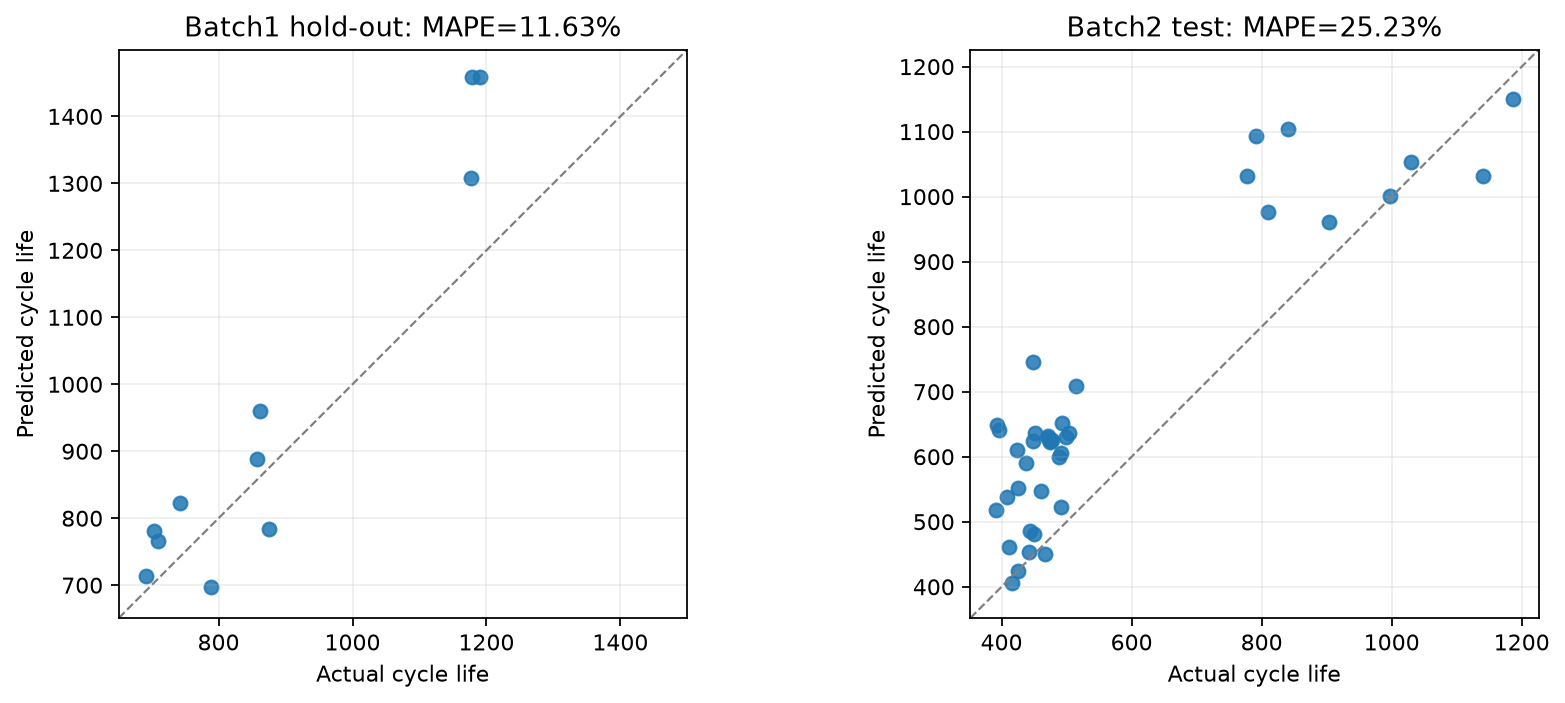

예측 수명 = **-1278.77 -546.04 × log10_dqv_var** (사이클).

선형회귀의 Train CV MAPE는 **7.60%**, Batch1 Hold-out은 **11.63%**, Batch2는 **25.23%**다. 목표 9.1%와의 차이는 **+16.13%p**다.

In [5]:
manifest = result["manifest"]
display(pd.DataFrame(manifest["coefficients"]).round(3))
display(pd.DataFrame(manifest["test_diagnostics"]).round(3))
display(Image(filename=str(OUT / "model_predictions.png")))
coef = manifest["coefficients"][0]["raw_coef"]
intercept = manifest["raw_intercept"]
display(Markdown(
    f"예측 수명 = **{intercept:.2f} {coef:+.2f} × log10_dqv_var** (사이클).\n\n"
    f"선형회귀의 Train CV MAPE는 **{manifest['train_cv_MAPE_pct']:.2f}%**, "
    f"Batch1 Hold-out은 **{manifest['evaluations']['valid']['MAPE_pct']:.2f}%**, "
    f"Batch2는 **{manifest['evaluations']['test']['MAPE_pct']:.2f}%**다. "
    f"목표 9.1%와의 차이는 **{manifest['gaps_pp']['Target-Test']:+.2f}%p**다."
))

## 5. 저장과 재현

`model/train_model.py`의 같은 함수를 노트북과 CLI에서 호출한다. 표준화와 선택 모델을 `battery_model.joblib`에 저장한다. Batch1 학습 35개에 적합한 모델을 유지하고 Hold-out을 합쳐 재학습하지 않는다.

모델 선정표·선정 규칙·파라미터·분할 셀·fold 점수·성능표·셀별 예측·계수를 남긴다. 실행 시각, 실제 라이브러리 버전, requirements와 입력 CSV의 SHA-256도 기록한다. 분할·나무 모델의 난수는 42이며 GroupKFold는 shuffle 없이 사용한다. 코드에서 프로토콜 중복, scaler 학습 범위, CV 1회 검증, 저장 모델·CSV 재현과 선정 파일의 평가 중 불변을 검사한다.

간단한 해석 범위: 작은 Batch1 표본의 특성 관계를 사용한 과제의 배치 간 평가이며 상관은 인과관계가 아니다. 실제 운영 평가는 별도 데이터에서 확인한다.

In [6]:
saved = pd.read_csv(OUT / "model_comparison.csv")
assert len(saved) == 20 and saved["CV_MAPE_pct"].notna().all()
assert manifest["features"] == ["log10_dqv_var"] and manifest["test_batch"] == "batch2"
assert np.isclose(manifest["gaps_pp"]["Target-Test"], manifest["evaluations"]["test"]["MAPE_pct"] - 9.1)
print("선정·평가·저장 결과 확인 완료:", OUT)

선정·평가·저장 결과 확인 완료: /Users/u102/workspace_public/021_Data_Analytics_Mini_Projcet/Data_Analytics_MiniProject_Skala/outputs
